# Tobacco Use and Mortality (2004–2015)
### Advanced df Science Project using Python & Machine Learning
This notebook explores the impact of tobacco use on mortality rates using supervised machine learning.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import shap
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [5]:
# Load the dfset
df = pd.read_csv("/content/tobacco_mortality.csv")
df.head()

,age,gender,income_level,education_level,age_started_smoking,cigarettes_per_day,pre_existing_conditions,healthcare_access,tobacco_use_duration,mortality
0,73,Male,Low,Primary,34,36,1,Good,39,1
1,63,Female,High,Tertiary,34,22,2,Good,29,1
2,49,Female,Low,Tertiary,31,12,0,Poor,18,0
3,77,Female,Low,Tertiary,26,31,4,Poor,51,1
4,42,Female,Medium,Tertiary,32,22,4,Poor,10,1


In [6]:
# Check df structure
print(df.info())
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   age                      1000 non-null   int64 
 1   gender                   1000 non-null   object
 2   income_level             1000 non-null   object
 3   education_level          1000 non-null   object
 4   age_started_smoking      1000 non-null   int64 
 5   cigarettes_per_day       1000 non-null   int64 
 6   pre_existing_conditions  1000 non-null   int64 
 7   healthcare_access        1000 non-null   object
 8   tobacco_use_duration     1000 non-null   int64 
 9   mortality                1000 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 78.3+ KB
None

Missing values:
 age                        0
gender                     0
income_level               0
education_level            0
age_started_smoking        0
cigarettes_per_day         0
pre_existi

## Exploratory df Analysis (EDA)

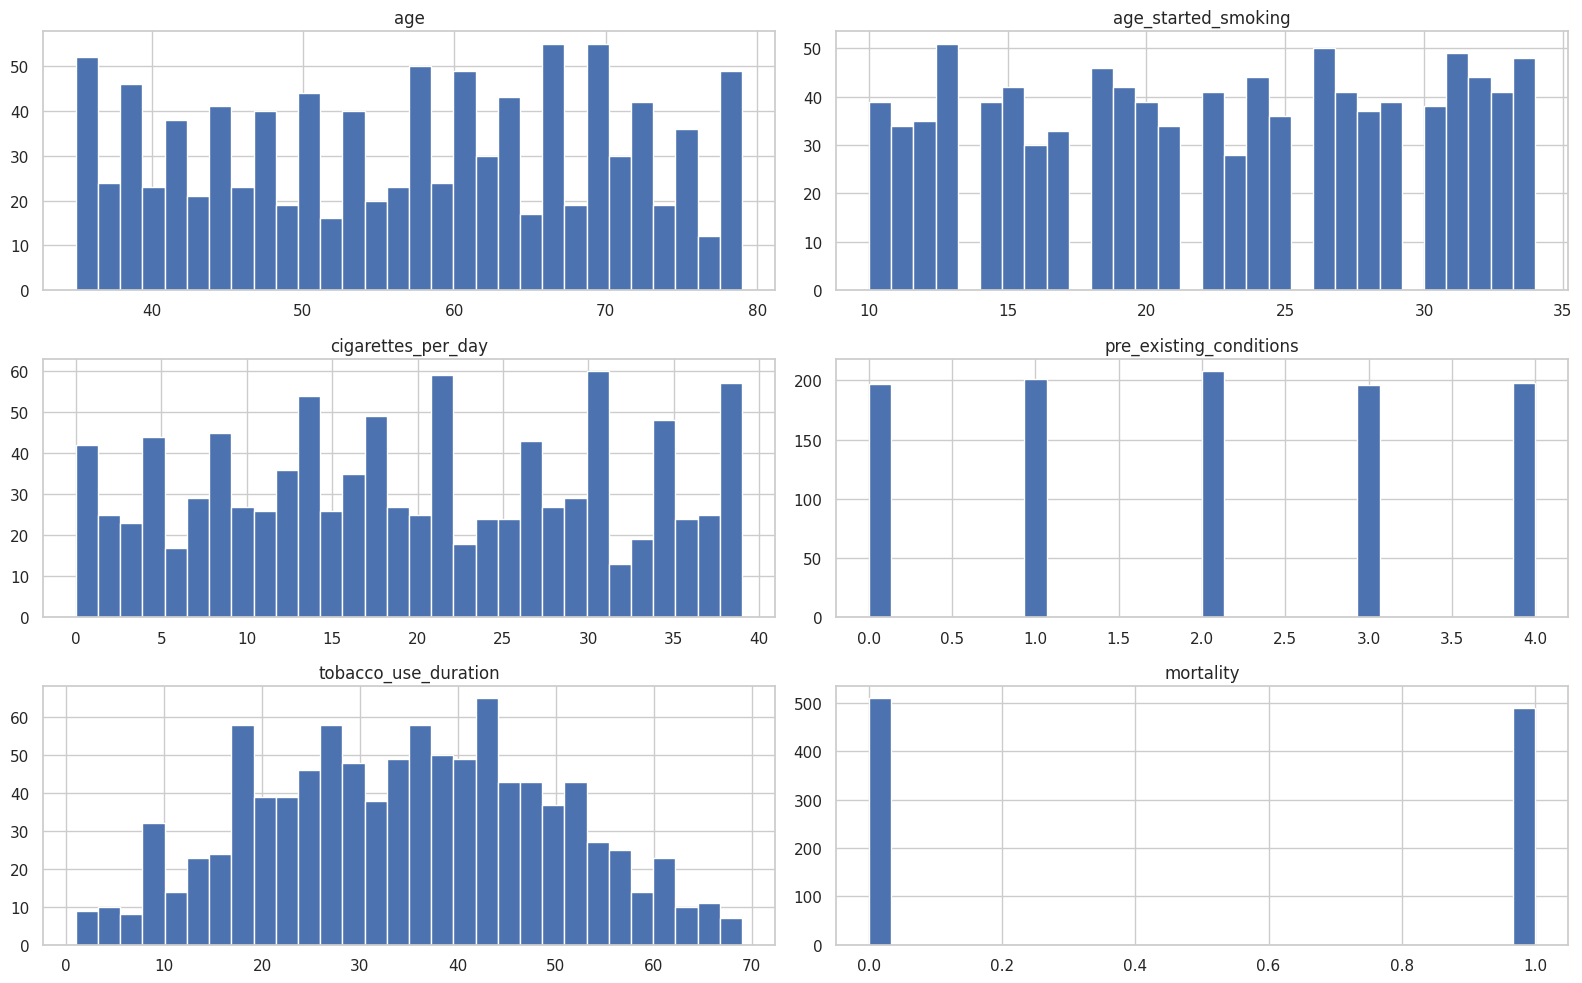

In [7]:
# Distribution of numeric features
df.hist(bins=30, figsize=(16, 10))
plt.tight_layout()
plt.show()

## Feature Engineering & Encoding

In [8]:
# One-hot encode categorical features
df = pd.get_dummies(df, columns=['gender', 'income_level', 'education_level', 'healthcare_access'], drop_first=True)
df.head()

,age,age_started_smoking,cigarettes_per_day,pre_existing_conditions,tobacco_use_duration,mortality,gender_Male,income_level_Low,income_level_Medium,education_level_Secondary,education_level_Tertiary,healthcare_access_Good,healthcare_access_Poor
0,73,34,36,1,39,1,True,True,False,False,False,True,False
1,63,34,22,2,29,1,False,False,False,False,True,True,False
2,49,31,12,0,18,0,False,True,False,False,True,False,True
3,77,26,31,4,51,1,False,True,False,False,True,False,True
4,42,32,22,4,10,1,False,False,True,False,True,False,True


In [9]:
# Define features and target
X = df.drop('mortality', axis=1)
y = df['mortality']

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training & Evaluation

In [10]:
# Train Logistic Regression and Random Forest
log_reg = LogisticRegression()
rf_clf = RandomForestClassifier(random_state=42)

log_reg.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

# Predict
log_reg_pred = log_reg.predict(X_test)
rf_clf_pred = rf_clf.predict(X_test)

# Evaluation function
def evaluate_model(y_true, y_pred, model_name):
    print(f"--- {model_name} ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_true, y_pred):.4f}")
    print(f"ROC AUC: {roc_auc_score(y_true, y_pred):.4f}\n")

evaluate_model(y_test, log_reg_pred, "Logistic Regression")
evaluate_model(y_test, rf_clf_pred, "Random Forest Classifier")

--- Logistic Regression ---
Accuracy: 0.8350
Precision: 0.8409
Recall: 0.7957
F1 Score: 0.8177
ROC AUC: 0.8324

--- Random Forest Classifier ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
ROC AUC: 1.0000



## Model Interpretation with SHAP

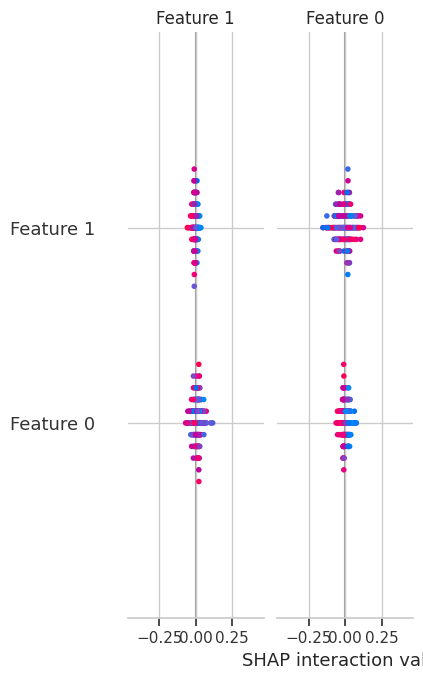

In [11]:
explainer = shap.Explainer(rf_clf, X_train)
shap_values = explainer(X_test, check_additivity=False)

# Summary plot
shap.summary_plot(shap_values, X_test)

## Model Deployment (Flask API Skeleton)

In [12]:
# Flask app skeleton for deployment
from flask import Flask, request, jsonify
import numpy as np

app = Flask(__name__)

@app.route('/predict', methods=['POST'])
def predict():
    df = request.get_json(force=True)
    features = np.array([df[key] for key in sorted(df.keys())]).reshape(1, -1)
    features = scaler.transform(features)
    prediction = rf_clf.predict(features)
    return jsonify({'prediction': int(prediction[0])})

# To run: app.run(debug=True)

In [13]:
app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with stat
